In [21]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams["figure.dpi"] = 120

with open("results_fashion/results.json") as f:
    results = json.load(f)

RNG_ENGINES = list(results.keys())
SEEDS = list(results[RNG_ENGINES[0]].keys())
print("PRNGs :", RNG_ENGINES)
print("Seeds :", SEEDS)

PRNGs : ['MT19937', 'PCG', 'PHILOX', 'LCG']
Seeds : ['53519', '12340', '53579', '3254789', '2358439', '197984568', '739592932190', '979592932190', '395929321950']


In [22]:
def compute_confidence_interval_95(data):
    h = stats.sem(data) * stats.t.ppf(0.975, len(data) - 1)
    return np.mean(data) - h, np.mean(data) + h

accuracies = {}
for prng_engine in RNG_ENGINES:
    accuracies[prng_engine] = []
    for s in results[prng_engine]:
        accuracies[prng_engine].append(results[prng_engine][s]["accuracies"][-1])

rows = []
for prng_engine in RNG_ENGINES:
    accs = accuracies[prng_engine]
    lo, hi = compute_confidence_interval_95(accs)
    entry = {
        "PRNG": prng_engine,
        "Mean": np.mean(accs),
        "Std": np.std(accs),
        "CI Low": lo,
        "CI High": hi,
        "n": len(accs)
    }
    rows.append(entry)

df = pd.DataFrame(rows).set_index("PRNG").round(4)
df

,Mean,Std,CI Low,CI High,n
PRNG,,,,,
MT19937,0.9180,0.0036,0.9151,0.9210,9
PCG,0.9164,0.0019,0.9149,0.9180,9
PHILOX,0.9185,0.0026,0.9164,0.9206,9
LCG,0.9169,0.0038,0.9138,0.9201,9


/tmp/ipykernel_74608/3469769663.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([accuracies[p] for p in RNG_ENGINES], labels=RNG_ENGINES, patch_artist=True)


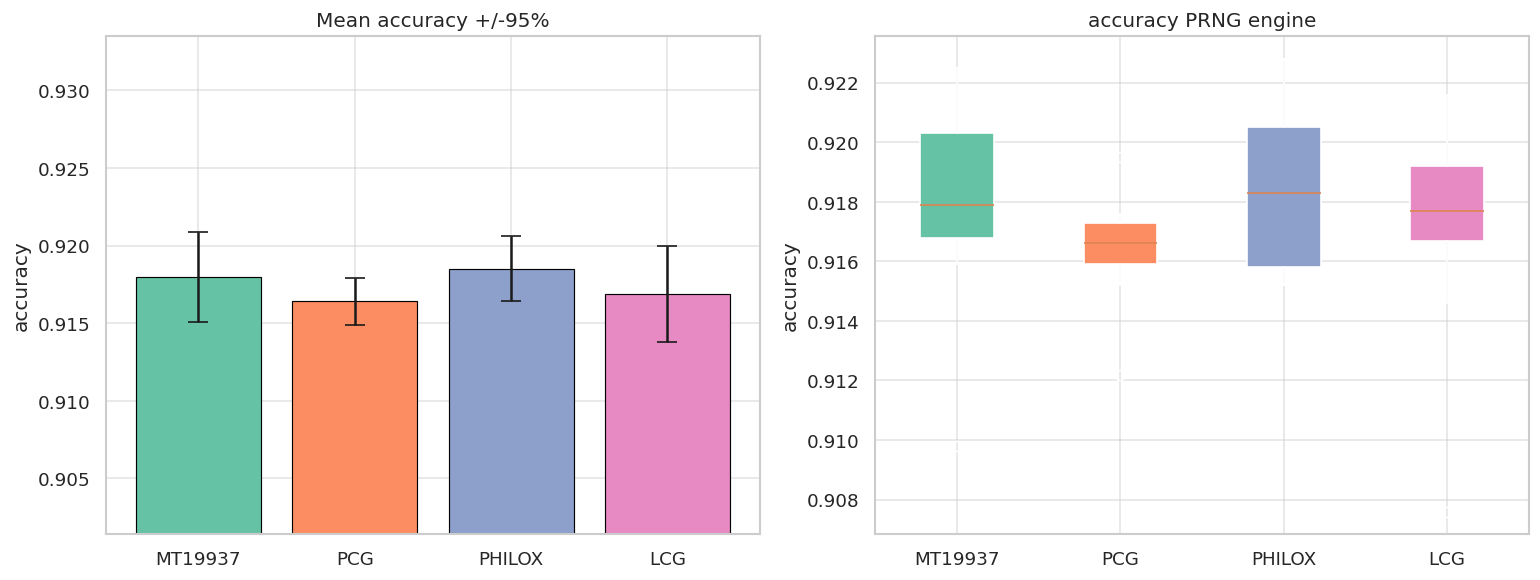

In [23]:
cfig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = sns.color_palette("Set2", len(RNG_ENGINES))
means  = df["Mean"].values
errors = np.nan_to_num(df["Mean"].values - df["CI Low"].values)

axes[0].bar(RNG_ENGINES, means, yerr=errors, capsize=6,
            color=colors, edgecolor="black", linewidth=0.7)
axes[0].set_ylabel("accuracy")
axes[0].set_title("Mean accuracy +/-95%")
pad = max(float(errors.max()), 0.005)
axes[0].set_ylim(max(0.0, float(means.min()) - pad * 3),
                 min(1.0, float(means.max()) + pad * 3))


bp = axes[1].boxplot([accuracies[p] for p in RNG_ENGINES], labels=RNG_ENGINES, patch_artist=True)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
axes[1].set_ylabel("accuracy")
axes[1].set_title("accuracy PRNG engine")

plt.tight_layout()
plt.show()

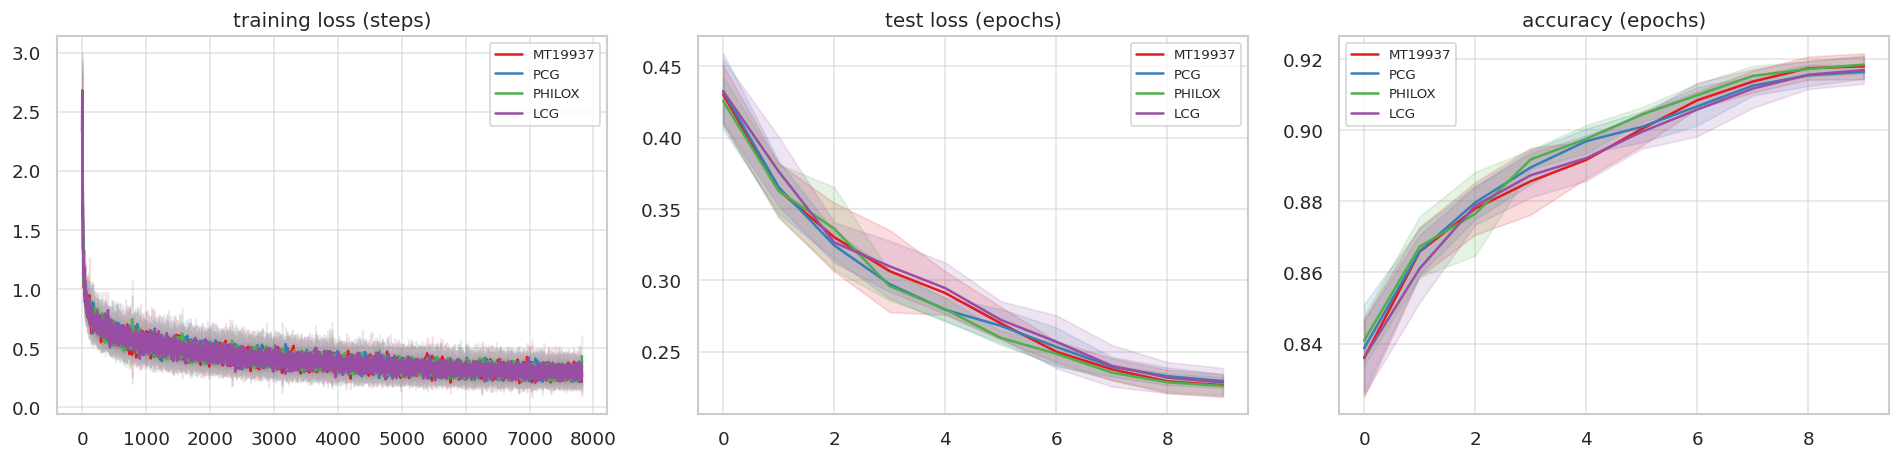

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
titles = ["training loss (steps)", "test loss (epochs)", "accuracy (epochs)"]
keys   = ["losses", "test_losses", "accuracies"]
colors = sns.color_palette("Set1", len(RNG_ENGINES))

for prng, color in zip(RNG_ENGINES, colors):
    current_seed_data = list(results[prng].values())

    for axe, key in zip(axes, keys):

        rows = []
        for d in current_seed_data:
            rows.append(d[key])
        matrix = np.array(rows, dtype=float)

        mean = matrix.mean(axis=0)
        x = np.arange(len(mean))

        axe.plot(x, mean, label=prng, color=color)

        if matrix.shape[0] > 1:
            std = matrix.std(axis=0)
            axe.fill_between(x, mean - std, mean + std, alpha=0.15, color=color)

for axe, title in zip(axes, titles):
    axe.set_title(title)
    axe.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [25]:
groups = []
for p in RNG_ENGINES:
    groups.append(accuracies[p])

min_n = len(groups[0])
for g in groups:
    if len(g) < min_n:
        min_n = len(g)

_, p_anova = stats.f_oneway(*groups)
_, p_kw    = stats.kruskal(*groups)

if p_anova < 0.05:
    anova_sig = "significant"
else:
    anova_sig = "not significant"

if p_kw < 0.05:
    kw_sig = "significant"
else:
    kw_sig = "not significant"

print(f"anova          p={p_anova:.4f}  {anova_sig}")
print(f"kruskalwallis  p={p_kw:.4f}  {kw_sig}")

anova          p=0.5248  not significant
kruskalwallis  p=0.3371  not significant
